# Dubai 유가와 환율 등 거시경제 변수를 활용한 다음 달 소비자물가 상승률 예측 모델 개발

## 프로젝트 개요

국제유가와 환율의 변동은 원유 수입가격과 국내 생산·운송비를 통해 소비자물가에 시차를 두고 반영될 수 있다. 본 프로젝트는 한국은행 ECOS의 월별 거시경제 데이터를 활용하여 **다음 달 소비자물가 상승률(CPI 전년 동월 대비)** 을 예측하고, Dubai 유가와 환율이 물가의 자기 지속성 외에 추가적인 예측 정보를 제공하는지 확인하는 것을 목적으로 한다.

### 주요 목표

1. 2005년 1월 이후의 Dubai 유가, 소비자물가지수, 원/달러 환율 및 기준금리를 월 단위로 통합한다.
2. 유가 변동률과 1·2·3·6개월 시차 변수를 생성하여 물가 반영 시차를 분석한다.
3. 2022년 이후를 테스트 구간으로 분리하여 미래 정보가 학습에 포함되지 않도록 한다.
4. 지속성 기준 모델, Linear Regression, Ridge, Random Forest, XGBoost를 비교한다.
5. 변수 제거 실험을 통해 유가 정보의 추가적인 예측 기여를 평가한다.

> 본 분석은 변수 간 예측 관계를 다루며, 유가가 물가 변동의 직접적인 원인임을 증명하는 인과분석은 아니다.


## 1. 분석 환경 및 원천 데이터

### 1.1 라이브러리와 데이터 로드

분석에는 `pandas`, `NumPy`, `Matplotlib`, `Seaborn`, `scikit-learn`, `XGBoost`를 사용한다. 원천 자료는 한국은행 ECOS에서 내려받은 CSV이며, 원본은 날짜가 열로 배치된 가로형 구조이다.

| 데이터 | 주요 항목 | 주기 | 활용 목적 |
|---|---|---:|---|
| 국제상품가격 | 원유-Dubai, 달러/배럴 | 월별 | 핵심 유가 변수 |
| 소비자물가지수 | 총지수, 2020=100 | 월별 | 예측 대상 산출 |
| 원/미국달러 환율 | 매매기준율 | 일별 | 월평균 및 변동률 산출 |
| 한국은행 기준금리 | 기준금리, 연% | 월별 | 보조 거시경제 변수 |


In [28]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from matplotlib import font_manager

DATA_DIR = Path("./dataset")

interest_df = pd.read_csv(DATA_DIR / "BankOfKoreaInterestRate.csv")
consumer_df = pd.read_csv(DATA_DIR / "ConsumerPriceIndex.csv")
dollar_df = pd.read_csv(DATA_DIR / "DollarExchangeRate.csv")
oil_df = pd.read_csv(DATA_DIR / "DubaiOilPrice.csv")

datasets = {
    "기준금리": interest_df,
    "소비자물가지수": consumer_df,
    "환율": dollar_df,
    "Dubai 유가": oil_df,
}

# 날짜 형식의 열만 선택
date_cols = [
    col for col in oil_df.columns
    if pd.Series([col]).str.fullmatch(r"\d{4}/\d{2}").iloc[0]
]

## 2. 데이터 전처리

### 2.1 Dubai 유가

`원유-Dubai`의 `원자료`만 선택한 뒤 날짜 열을 행으로 전환한다. 최종적으로 `date`, `dubai_price` 두 열을 가진 월별 데이터로 정리한다.


In [3]:
# Dubai 유가의 원자료 행 선택
oil_monthly = oil_df.loc[
    oil_df["계정항목"].str.contains("Dubai", na=False)
    & oil_df["변환"].eq("원자료"),
    date_cols
]

# 가로형에서 세로형으로 변환
oil_monthly = oil_monthly.T.reset_index()
oil_monthly.columns = ["date", "dubai_price"]

# 자료형 변환
oil_monthly["date"] = pd.to_datetime(
    oil_monthly["date"],
    format="%Y/%m"
)
oil_monthly["dubai_price"] = pd.to_numeric(
    oil_monthly["dubai_price"],
    errors="coerce"
)
oil_monthly.head()

,date,dubai_price
0,2005-01-01,38.32
1,2005-02-01,39.67
2,2005-03-01,46.08
3,2005-04-01,47.10
4,2005-05-01,45.07


### 2.2 소비자물가지수

세부 품목을 제외하고 `총지수`의 `원자료`만 사용한다. CPI 지수 자체는 장기 추세가 있으므로 이후 전년 동월 대비 상승률로 변환하여 예측 대상으로 활용한다.


In [4]:
# CPI 총지수 행 선택
cpi_monthly = consumer_df.loc[
    consumer_df["계정항목"].str.strip().eq("총지수")
    & consumer_df["변환"].eq("원자료"),
    date_cols
]

cpi_monthly = cpi_monthly.T.reset_index()
cpi_monthly.columns = ["date", "cpi_index"]

cpi_monthly["date"] = pd.to_datetime(
    cpi_monthly["date"],
    format="%Y/%m"
)
cpi_monthly["cpi_index"] = pd.to_numeric(
    cpi_monthly["cpi_index"],
    errors="coerce"
)
cpi_monthly.head()

,date,cpi_index
0,2005-01-01,73.594
1,2005-02-01,73.892
2,2005-03-01,74.338
3,2005-04-01,74.413
4,2005-05-01,74.338


### 2.3 한국은행 기준금리

`한국은행 기준금리`의 `원자료`를 선택하고 월별 세로형 데이터로 변환한다. 기준금리는 물가에 영향을 줄 수 있지만 물가에 대응하여 조정되기도 하므로 인과효과가 아닌 보조 예측변수로 해석한다.


In [5]:
interest_monthly = interest_df.loc[
    interest_df["계정항목"].str.strip().eq("한국은행 기준금리")
    & interest_df["변환"].eq("원자료"),
    date_cols
]

interest_monthly = interest_monthly.T.reset_index()
interest_monthly.columns = ["date", "base_rate"]

interest_monthly["date"] = pd.to_datetime(
    interest_monthly["date"],
    format="%Y/%m"
)
interest_monthly["base_rate"] = pd.to_numeric(
    interest_monthly["base_rate"],
    errors="coerce"
)

interest_monthly.head()

,date,base_rate
0,2005-01-01,3.25
1,2005-02-01,3.25
2,2005-03-01,3.25
3,2005-04-01,3.25
4,2005-05-01,3.25


### 2.4 원/달러 환율

일별 매매기준율을 세로형으로 변환한 후 월평균을 계산한다. 천 단위 쉼표를 제거한 뒤 숫자형으로 변환하여 다른 월별 데이터와 주기를 맞춘다.


In [6]:
# 환율 파일의 일별 날짜 열 선택
daily_date_cols = [
    col for col in dollar_df.columns
    if pd.Series([col]).str.fullmatch(r"\d{4}/\d{2}/\d{2}").iloc[0]
]

# 원/달러 환율 원자료 선택
exchange_daily = dollar_df.loc[
    dollar_df["계정항목"].str.contains("원/미국달러", na=False)
    & dollar_df["변환"].eq("원자료"),
    daily_date_cols
]

# 세로형 변환
exchange_daily = exchange_daily.T.reset_index()
exchange_daily.columns = ["date", "usd_krw"]

exchange_daily["date"] = pd.to_datetime(
    exchange_daily["date"],
    format="%Y/%m/%d"
)
exchange_daily["usd_krw"] = pd.to_numeric(
    exchange_daily["usd_krw"]
    .astype(str)
    .str.replace(",", "", regex=False),
    errors="coerce"
)

# 일별 환율을 월평균으로 변환
exchange_monthly = (
    exchange_daily
    .set_index("date")
    .resample("MS")["usd_krw"]
    .mean()
    .reset_index()
)

print(exchange_monthly.shape)
print(exchange_monthly.isna().sum())

display(exchange_monthly.head())
display(exchange_monthly.tail())

(258, 2)
date       0
usd_krw    0
dtype: int64


,date,usd_krw
0,2005-01-01,1038.233333
1,2005-02-01,1022.429412
2,2005-03-01,1007.490909
3,2005-04-01,1010.935000
4,2005-05-01,1002.214286


,date,usd_krw
253,2026-02-01,1449.323529
254,2026-03-01,1486.638095
255,2026-04-01,1487.390909
256,2026-05-01,1490.105556
257,2026-06-01,1521.150000


### 2.5 월별 통합 데이터셋

네 데이터셋을 `date` 기준의 내부 조인으로 병합한다. 병합 결과는 2005년 1월부터 2026년 5월까지 257개월이며, 각 월은 한 번만 존재하고 결측치는 없다.


In [7]:
monthly_df = (
    oil_monthly
    .merge(cpi_monthly, on="date", how="inner", validate="one_to_one")
    .merge(interest_monthly, on="date", how="inner", validate="one_to_one")
    .merge(exchange_monthly, on="date", how="inner", validate="one_to_one")
    .sort_values("date")
    .reset_index(drop=True)
)

print("데이터 크기:", monthly_df.shape)
print("\n변수별 결측치:")
print(monthly_df.isna().sum())
print(monthly_df["date"].min(), monthly_df["date"].max())

display(monthly_df.head())
display(monthly_df.tail())

데이터 크기: (257, 5)

변수별 결측치:
date           0
dubai_price    0
cpi_index      0
base_rate      0
usd_krw        0
dtype: int64
2005-01-01 00:00:00 2026-05-01 00:00:00


,date,dubai_price,cpi_index,base_rate,usd_krw
0,2005-01-01,38.32,73.594,3.25,1038.233333
1,2005-02-01,39.67,73.892,3.25,1022.429412
2,2005-03-01,46.08,74.338,3.25,1007.490909
3,2005-04-01,47.10,74.413,3.25,1010.935000
4,2005-05-01,45.07,74.338,3.25,1002.214286


,date,dubai_price,cpi_index,base_rate,usd_krw
252,2026-01-01,62.73,118.03,2.5,1456.509524
253,2026-02-01,68.51,118.40,2.5,1449.323529
254,2026-03-01,126.71,118.80,2.5,1486.638095
255,2026-04-01,105.30,119.37,2.5,1487.390909
256,2026-05-01,102.28,119.92,2.5,1490.105556


### 2.6 파생변수 및 예측 대상 생성

| 변수 | 정의 |
|---|---|
| `cpi_yoy` | CPI의 전년 동월 대비 상승률 |
| `oil_mom` | Dubai 유가의 전월 대비 변동률 |
| `fx_mom` | 원/달러 환율의 전월 대비 변동률 |
| `krw_oil_price` | Dubai 유가 × 원/달러 환율 |
| `oil_lag_n` | 유가 변동률의 n개월 시차 |
| `target_cpi_yoy` | 다음 달 CPI 전년 동월 대비 상승률 |

초기 12개월과 마지막 1개월의 결측치는 시차 및 타깃 이동 과정에서 발생하는 정상적인 결측치이며 모델링 데이터 구성 시 제거한다.


In [8]:
analysis_df = monthly_df.copy()

# 소비자물가 전년 동월 대비 상승률
analysis_df["cpi_yoy"] = (
    analysis_df["cpi_index"].pct_change(12) * 100
)

# Dubai 유가 월간 변동률
analysis_df["oil_mom"] = (
    analysis_df["dubai_price"].pct_change() * 100
)

# 환율 월간 변동률
analysis_df["fx_mom"] = (
    analysis_df["usd_krw"].pct_change() * 100
)

# 원화 환산 원유 가격
analysis_df["krw_oil_price"] = (
    analysis_df["dubai_price"] * analysis_df["usd_krw"]
)

# 유가 변동의 시차 변수
for lag in [1, 2, 3, 6]:
    analysis_df[f"oil_lag_{lag}"] = analysis_df["oil_mom"].shift(lag)

# 다음 달 물가상승률을 예측 대상으로 설정
analysis_df["target_cpi_yoy"] = analysis_df["cpi_yoy"].shift(-1)

display(analysis_df.head(15))
print(analysis_df.isna().sum())

,date,dubai_price,cpi_index,base_rate,usd_krw,cpi_yoy,oil_mom,fx_mom,krw_oil_price,oil_lag_1,oil_lag_2,oil_lag_3,oil_lag_6,target_cpi_yoy
0,2005-01-01,38.32,73.594,3.25,1038.233333,NaN,NaN,NaN,39785.101333,NaN,NaN,NaN,NaN,NaN
1,2005-02-01,39.67,73.892,3.25,1022.429412,NaN,3.522965,-1.522194,40559.774765,NaN,NaN,NaN,NaN,NaN
2,2005-03-01,46.08,74.338,3.25,1007.490909,NaN,16.158306,-1.461079,46425.181091,3.522965,NaN,NaN,NaN,NaN
3,2005-04-01,47.10,74.413,3.25,1010.935000,NaN,2.213542,0.341848,47615.038500,16.158306,3.522965,NaN,NaN,NaN
4,2005-05-01,45.07,74.338,3.25,1002.214286,NaN,-4.309979,-0.862638,45169.797857,2.213542,16.158306,3.522965,NaN,NaN
5,2005-06-01,51.10,74.114,3.25,1010.871429,NaN,13.379188,0.863802,51655.530000,-4.309979,2.213542,16.158306,NaN,NaN
6,2005-07-01,52.98,74.413,3.25,1037.442857,NaN,3.679061,2.628567,54963.722571,13.379188,-4.309979,2.213542,NaN,NaN
7,2005-08-01,56.83,74.636,3.25,1021.172727,NaN,7.266893,-1.568292,58033.246091,3.679061,13.379188,-4.309979,3.522965,NaN
8,2005-09-01,56.93,75.008,3.25,1029.333333,NaN,0.175963,0.799141,58599.946667,7.266893,3.679061,13.379188,16.158306,NaN
9,2005-10-01,53.58,74.859,3.50,1046.250000,NaN,-5.884419,1.643459,56058.075000,0.175963,7.266893,3.679061,2.213542,NaN


date               0
dubai_price        0
cpi_index          0
base_rate          0
usd_krw            0
cpi_yoy           12
oil_mom            1
fx_mom             1
krw_oil_price      0
oil_lag_1          2
oil_lag_2          3
oil_lag_3          4
oil_lag_6          7
target_cpi_yoy    12
dtype: int64


## 3. 탐색적 데이터 분석

### 3.1 기술통계 및 시계열 추이

유가, 소비자물가 상승률, 환율, 기준금리의 분포와 시간 흐름을 확인한다. 2008년 금융위기, 2020년 코로나19, 2022년 국제 원자재가격 상승기처럼 변동성이 큰 구간은 실제 경제 현상이므로 단순 오류로 간주해 제거하지 않는다.


,count,mean,std,min,25%,50%,75%,max
dubai_price,257.0,73.999767,22.901337,26.190000,56.830000,71.760000,90.870000,130.080000
cpi_index,257.0,95.172665,12.115363,73.594000,86.041000,94.966000,101.040000,119.920000
cpi_yoy,245.0,2.282421,1.369821,-0.426058,1.252663,2.094103,3.103511,6.327010
base_rate,257.0,2.506809,1.191483,0.500000,1.500000,2.500000,3.250000,5.250000
usd_krw,257.0,1159.624185,136.919437,915.859091,1076.973684,1134.404762,1220.086364,1490.105556
oil_mom,256.0,0.869887,10.147781,-38.001850,-4.118959,1.443250,6.108781,84.951102
fx_mom,256.0,0.166767,2.290532,-8.213658,-1.039840,0.070903,1.305471,17.385238


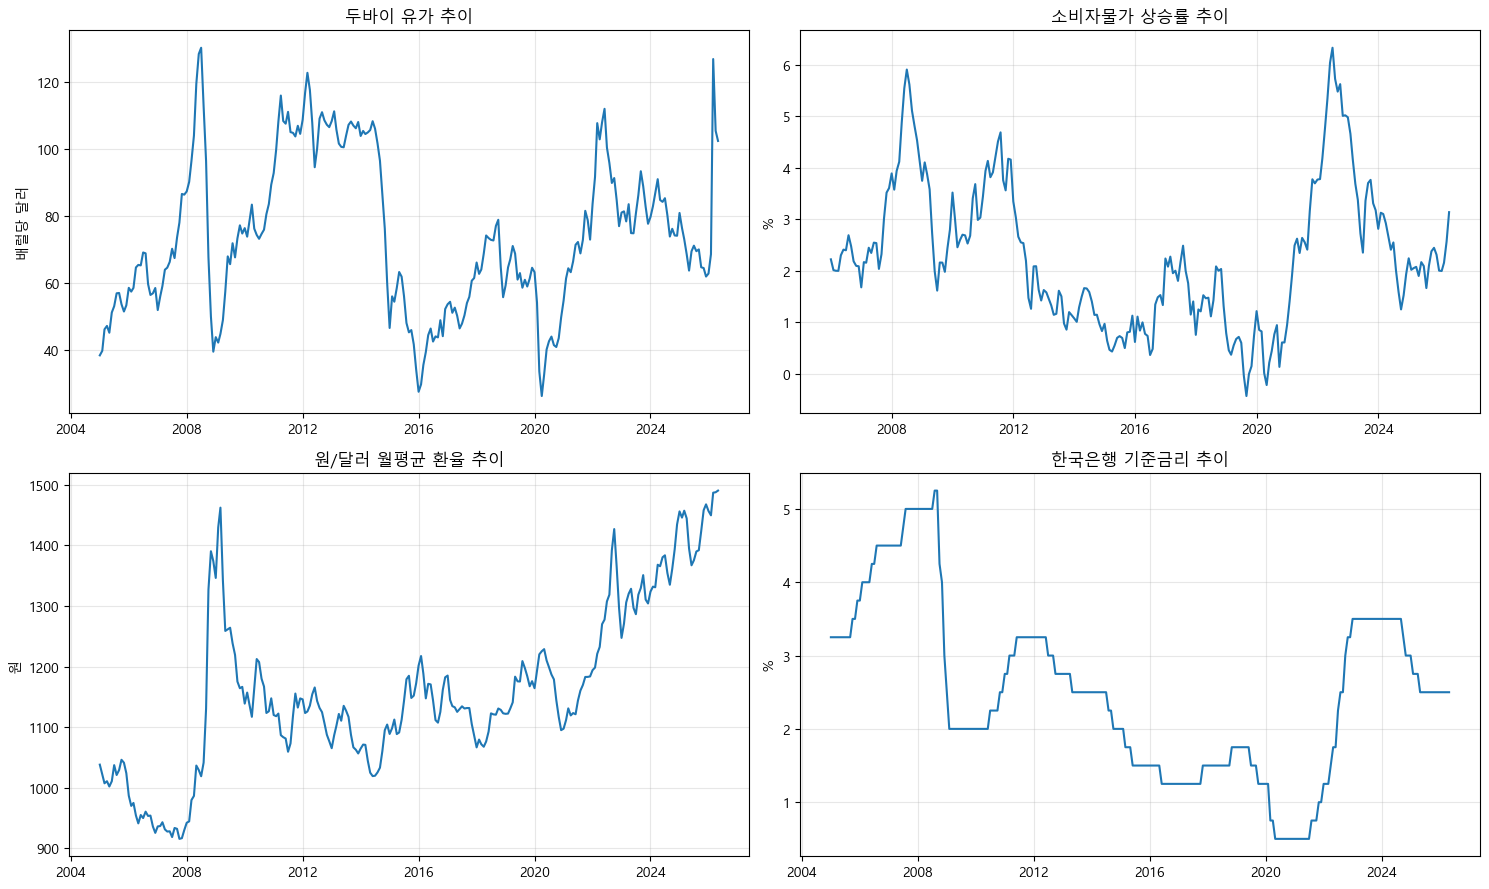

In [30]:
# 한글 폰트 설정
font_path = r"C:\Windows\Fonts\malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

# 주요 변수의 기술통계
display(
    analysis_df[
        ["dubai_price", "cpi_index", "cpi_yoy",
         "base_rate", "usd_krw", "oil_mom", "fx_mom"]
    ].describe().T
)

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

axes[0, 0].plot(analysis_df["date"], analysis_df["dubai_price"])
axes[0, 0].set_title("두바이 유가 추이")
axes[0, 0].set_ylabel("배럴당 달러")

axes[0, 1].plot(analysis_df["date"], analysis_df["cpi_yoy"])
axes[0, 1].set_title("소비자물가 상승률 추이")
axes[0, 1].set_ylabel("%")

axes[1, 0].plot(analysis_df["date"], analysis_df["usd_krw"])
axes[1, 0].set_title("원/달러 월평균 환율 추이")
axes[1, 0].set_ylabel("원")

axes[1, 1].plot(analysis_df["date"], analysis_df["base_rate"])
axes[1, 1].set_title("한국은행 기준금리 추이")
axes[1, 1].set_ylabel("%")

for ax in axes.flat:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.2 유가 시차별 상관관계

당월 및 1·2·3·6개월 시차 유가 변동률과 다음 달 물가상승률의 선형 상관관계를 비교한다. `oil_lag_6`의 상관계수가 약 0.19로 가장 높아 물가 반영에 시차가 존재할 가능성을 보여주지만, 상관 자체는 약하므로 인과관계로 해석하지 않는다.


6개월 전 유가 변동률    0.187868
2개월 전 유가 변동률    0.110556
3개월 전 유가 변동률    0.105020
1개월 전 유가 변동률    0.094756
당월 유가 변동률       0.049216
Name: target_cpi_yoy, dtype: float64

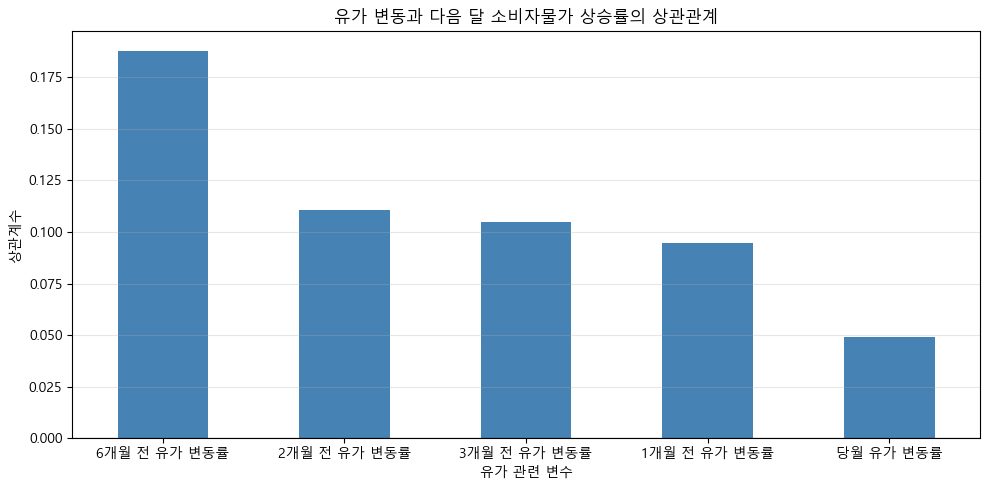

In [35]:
# 시차별 상관관계 분석
lag_columns = [
    "oil_mom",
    "oil_lag_1",
    "oil_lag_2",
    "oil_lag_3",
    "oil_lag_6",
]

lag_correlations = (
    analysis_df[lag_columns + ["target_cpi_yoy"]]
    .corr()["target_cpi_yoy"]
    .drop("target_cpi_yoy")
    .sort_values(ascending=False)
)

# 변수명 한글 변환
label_map = {
    "oil_mom": "당월 유가 변동률",
    "oil_lag_1": "1개월 전 유가 변동률",
    "oil_lag_2": "2개월 전 유가 변동률",
    "oil_lag_3": "3개월 전 유가 변동률",
    "oil_lag_6": "6개월 전 유가 변동률",
}

lag_correlations_ko = lag_correlations.rename(index=label_map)

display(lag_correlations_ko)

plt.figure(figsize=(10, 5))
lag_correlations_ko.plot(kind="bar", color="steelblue")

plt.title("유가 변동과 다음 달 소비자물가 상승률의 상관관계")
plt.xlabel("유가 관련 변수")
plt.ylabel("상관계수")
plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 3.3 전체 변수 상관관계

현재 물가상승률과 다음 달 물가상승률의 상관계수는 0.96으로 강한 자기 지속성을 보였다. 기준금리는 0.46, 유가 6개월 시차와 환율 변동률은 각각 0.19와 0.17이었다. 유가 시차 변수 사이에는 심각한 다중공선성이 확인되지 않았다.


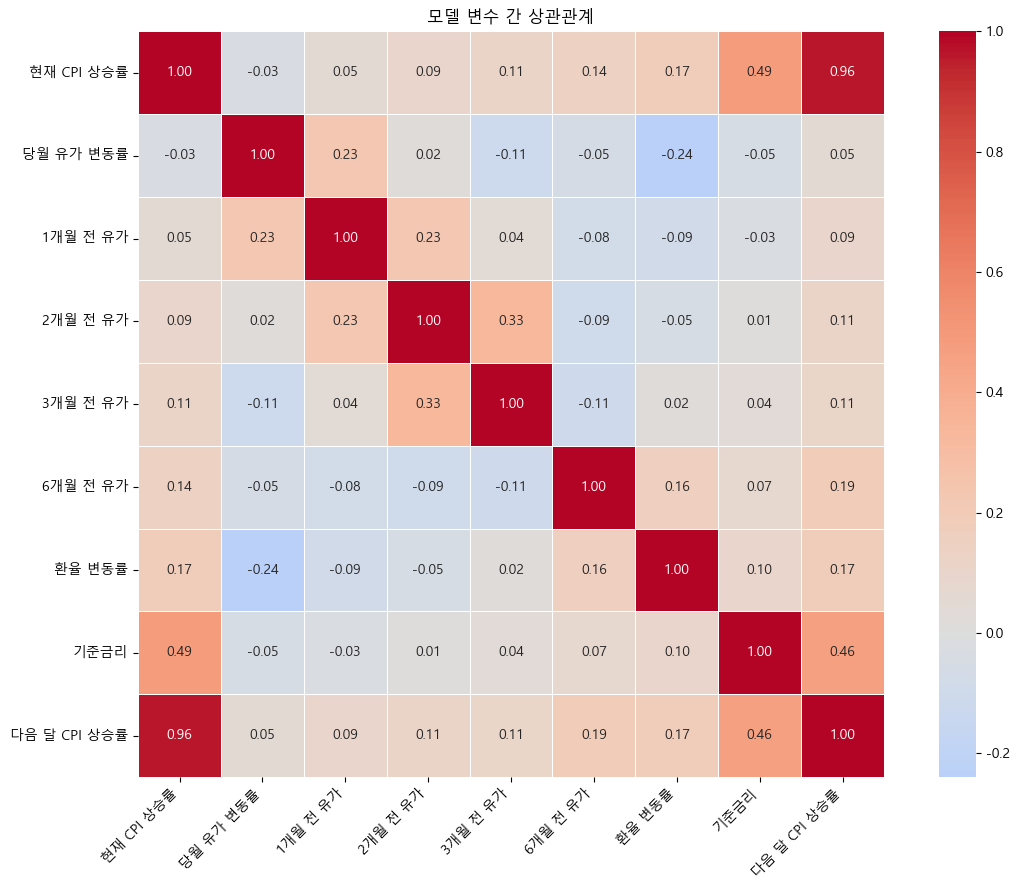

In [36]:
# 전체 모델 변수의 상관관계 히트맵
corr_columns = [
    "cpi_yoy",
    "oil_mom",
    "oil_lag_1",
    "oil_lag_2",
    "oil_lag_3",
    "oil_lag_6",
    "fx_mom",
    "base_rate",
    "target_cpi_yoy",
]

correlation_matrix = analysis_df[corr_columns].corr()

# 히트맵 출력용 한글 변수명
label_map = {
    "cpi_yoy": "현재 CPI 상승률",
    "oil_mom": "당월 유가 변동률",
    "oil_lag_1": "1개월 전 유가",
    "oil_lag_2": "2개월 전 유가",
    "oil_lag_3": "3개월 전 유가",
    "oil_lag_6": "6개월 전 유가",
    "fx_mom": "환율 변동률",
    "base_rate": "기준금리",
    "target_cpi_yoy": "다음 달 CPI 상승률",
}

correlation_matrix_ko = correlation_matrix.rename(
    index=label_map,
    columns=label_map,
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix_ko,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
)

plt.title("모델 변수 간 상관관계")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. 모델링 설계

### 4.1 입력변수와 시계열 분할

현재 물가상승률, Dubai 유가 변동률과 시차 변수, 환율 변동률, 기준금리를 이용해 다음 달 물가상승률을 예측한다. 무작위 분할 대신 2006년 2월~2021년 12월의 191개월을 학습 데이터, 2022년 1월~2025년 12월의 48개월을 테스트 데이터로 사용한다.


In [12]:
# 모델링 데이터 확정과 시계열 분할
feature_columns = [
    "cpi_yoy",
    "oil_mom",
    "oil_lag_1",
    "oil_lag_2",
    "oil_lag_3",
    "oil_lag_6",
    "fx_mom",
    "base_rate",
]

# 예측 대상 월 표시
analysis_df["target_date"] = (
    analysis_df["date"] + pd.offsets.MonthBegin(1)
)

# 학습에 필요한 값이 모두 존재하는 행만 선택
model_df = analysis_df.dropna(
    subset=feature_columns + ["target_cpi_yoy"]
).copy()

# 완결된 2025년까지만 사용
model_df = model_df[
    model_df["target_date"] <= "2025-12-01"
].reset_index(drop=True)

# 예측 대상 월을 기준으로 시계열 분할
train_df = model_df[
    model_df["target_date"] < "2022-01-01"
].copy()

test_df = model_df[
    model_df["target_date"] >= "2022-01-01"
].copy()

X_train = train_df[feature_columns]
y_train = train_df["target_cpi_yoy"]

X_test = test_df[feature_columns]
y_test = test_df["target_cpi_yoy"]

print("전체:", model_df.shape)
print("학습:", X_train.shape)
print("테스트:", X_test.shape)

print(
    "학습 기간:",
    train_df["target_date"].min(),
    "~",
    train_df["target_date"].max()
)
print(
    "테스트 기간:",
    test_df["target_date"].min(),
    "~",
    test_df["target_date"].max()
)

전체: (239, 15)
학습: (191, 8)
테스트: (48, 8)
학습 기간: 2006-02-01 00:00:00 ~ 2021-12-01 00:00:00
테스트 기간: 2022-01-01 00:00:00 ~ 2025-12-01 00:00:00


### 4.2 지속성 기준 모델

현재 물가상승률이 다음 달에도 유지된다고 가정한 기준 모델은 MAE 0.3098, RMSE 0.3759, R² 0.9214를 기록했다. 후보 모델은 이 기준보다 실제 오차를 줄여야 의미가 있다.


기준 모델 MAE:  0.3098
기준 모델 RMSE: 0.3759
기준 모델 R²:   0.9214


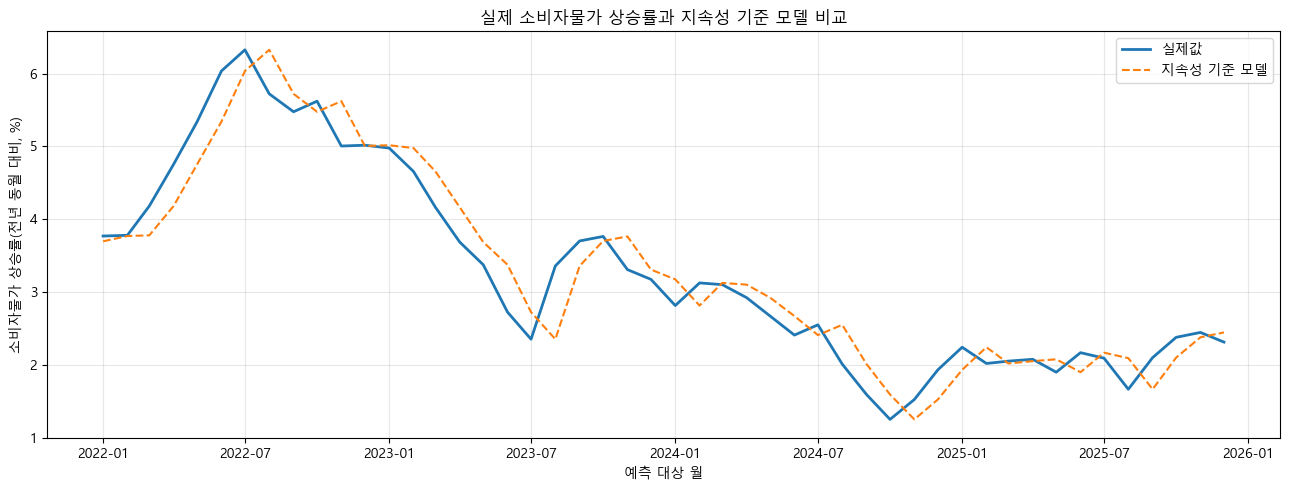

In [37]:
baseline_pred = test_df["cpi_yoy"]

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(
    mean_squared_error(y_test, baseline_pred)
)
baseline_r2 = r2_score(y_test, baseline_pred)

print(f"기준 모델 MAE:  {baseline_mae:.4f}")
print(f"기준 모델 RMSE: {baseline_rmse:.4f}")
print(f"기준 모델 R²:   {baseline_r2:.4f}")

plt.figure(figsize=(13, 5))

plt.plot(
    test_df["target_date"],
    y_test,
    label="실제값",
    linewidth=2
)

plt.plot(
    test_df["target_date"],
    baseline_pred,
    label="지속성 기준 모델",
    linestyle="--"
)

plt.title("실제 소비자물가 상승률과 지속성 기준 모델 비교")
plt.xlabel("예측 대상 월")
plt.ylabel("소비자물가 상승률(전년 동월 대비, %)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.3 Linear Regression

수치형 변수의 단위를 통일한 다중선형회귀는 MAE 0.3036, RMSE 0.3602, R² 0.9278을 기록하여 기준 모델보다 RMSE를 약 4.2% 줄였다.


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])

linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_pred)
)
linear_r2 = r2_score(y_test, linear_pred)

print(f"Linear Regression MAE:  {linear_mae:.4f}")
print(f"Linear Regression RMSE: {linear_rmse:.4f}")
print(f"Linear Regression R²:   {linear_r2:.4f}")

Linear Regression MAE:  0.3036
Linear Regression RMSE: 0.3602
Linear Regression R²:   0.9278


#### 초기 모델 비교

지속성 기준 모델과 Linear Regression을 먼저 비교한 뒤 같은 학습·테스트 구간에서 비선형 트리 모델을 평가한다.


In [15]:
comparison_df = pd.DataFrame({
    "Model": [
        "Persistence Baseline",
        "Linear Regression",
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
    ],
    "R2": [
        baseline_r2,
        linear_r2,
    ],
})

display(comparison_df)

,Model,MAE,RMSE,R2
0,Persistence Baseline,0.309799,0.375895,0.921387
1,Linear Regression,0.303580,0.360205,0.927812


### 4.4 Random Forest

Random Forest는 RMSE 0.4248, R² 0.8996으로 선형회귀보다 낮았다. 학습 범위 밖의 시계열 추세를 외삽하는 트리 모델의 한계가 영향을 준 것으로 해석된다.


In [16]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest MAE:  {rf_mae:.4f}")
print(f"Random Forest RMSE: {rf_rmse:.4f}")
print(f"Random Forest R²:   {rf_r2:.4f}")

comparison_df.loc[len(comparison_df)] = {
    "Model": "Random Forest",
    "MAE": rf_mae,
    "RMSE": rf_rmse,
    "R2": rf_r2,
}

display(comparison_df)

Random Forest MAE:  0.3374
Random Forest RMSE: 0.4248
Random Forest R²:   0.8996


,Model,MAE,RMSE,R2
0,Persistence Baseline,0.309799,0.375895,0.921387
1,Linear Regression,0.303580,0.360205,0.927812
2,Random Forest,0.337438,0.424776,0.899611


### 4.5 XGBoost

XGBoost는 RMSE 0.5758, R² 0.8156으로 후보 중 가장 낮았다. 작은 표본과 2022년 이후 급격한 물가 변화가 트리 기반 모델의 일반화에 불리하게 작용한 것으로 판단된다.


In [17]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=2,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_pred)
)
xgb_r2 = r2_score(y_test, xgb_pred)

comparison_df.loc[len(comparison_df)] = {
    "Model": "XGBoost",
    "MAE": xgb_mae,
    "RMSE": xgb_rmse,
    "R2": xgb_r2,
}

display(comparison_df)

,Model,MAE,RMSE,R2
0,Persistence Baseline,0.309799,0.375895,0.921387
1,Linear Regression,0.303580,0.360205,0.927812
2,Random Forest,0.337438,0.424776,0.899611
3,XGBoost,0.413830,0.575769,0.815557


## 5. 유가 변수의 추가 예측 기여

높은 예측력이 과거 CPI의 지속성에서만 발생했는지 확인하기 위해 `CPI Only`, `CPI + FX + Rate`, `Full Model (+ Oil)`을 비교한다. Full Model의 RMSE는 0.3602로 CPI 단독 대비 약 3.2%, 유가 제외 모델 대비 약 5.6% 개선되었다. 이는 유가 변수가 소폭의 추가 예측 정보를 제공했음을 시사한다.


In [18]:
ablation_features = {
    "CPI Only": [
        "cpi_yoy",
    ],
    "CPI + FX + Rate": [
        "cpi_yoy",
        "fx_mom",
        "base_rate",
    ],
    "Full Model (+ Oil)": feature_columns,
}

ablation_results = []
ablation_models = {}

for model_name, columns in ablation_features.items():
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ])

    model.fit(train_df[columns], y_train)
    pred = model.predict(test_df[columns])

    ablation_models[model_name] = model

    ablation_results.append({
        "Model": model_name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred),
    })

ablation_df = pd.DataFrame(ablation_results)
display(ablation_df)

,Model,MAE,RMSE,R2
0,CPI Only,0.307066,0.372188,0.922929
1,CPI + FX + Rate,0.313970,0.381761,0.918914
2,Full Model (+ Oil),0.303580,0.360205,0.927812


## 6. 최종 모델 분석

### 6.1 실제값·예측값 및 잔차

최종 선형모델은 전반적인 추세를 잘 추종하지만 급등 초기에는 상승 폭을 과소 예측하고 하락 전환기에는 변화를 늦게 따라가는 경향이 있다. 잔차는 대체로 0 주변에 분포하지만 일부 구간에서 같은 부호가 연속된다.


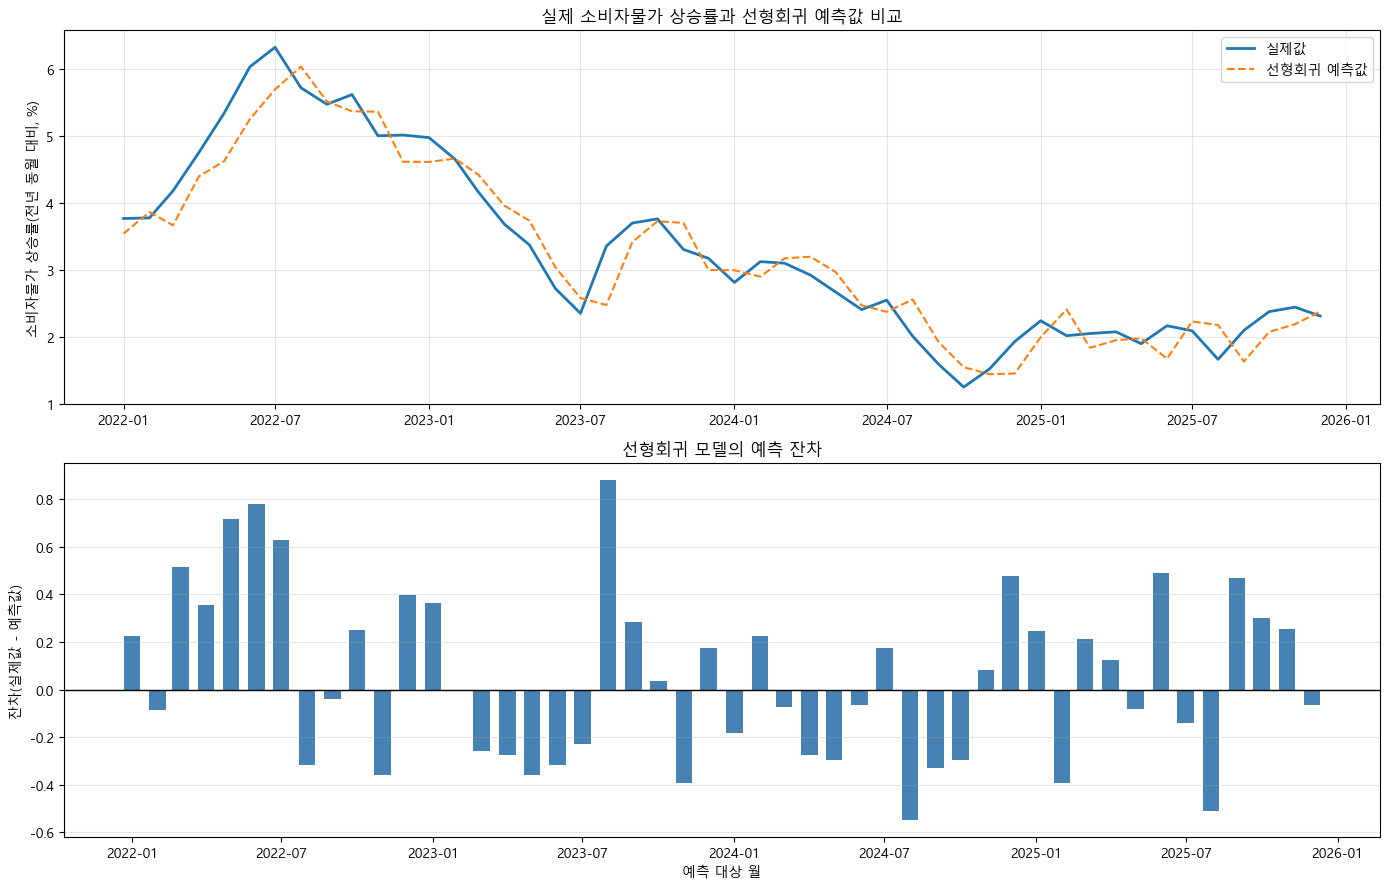

In [38]:
final_model = ablation_models["Full Model (+ Oil)"]
final_pred = final_model.predict(X_test)

# 잔차 = 실제값 - 예측값
residuals = y_test.to_numpy() - final_pred

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# 실제값과 예측값 비교
axes[0].plot(
    test_df["target_date"],
    y_test,
    label="실제값",
    linewidth=2
)

axes[0].plot(
    test_df["target_date"],
    final_pred,
    label="선형회귀 예측값",
    linestyle="--"
)

axes[0].set_title("실제 소비자물가 상승률과 선형회귀 예측값 비교")
axes[0].set_ylabel("소비자물가 상승률(전년 동월 대비, %)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# 예측 잔차
axes[1].bar(
    test_df["target_date"],
    residuals,
    width=20,
    color="steelblue"
)

axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("선형회귀 모델의 예측 잔차")
axes[1].set_xlabel("예측 대상 월")
axes[1].set_ylabel("잔차(실제값 - 예측값)")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 6.2 표준화 회귀계수

현재 물가상승률이 압도적으로 큰 계수를 보였고, 유가 변수 중 당월 변동률과 6개월 시차 변동률의 계수가 상대적으로 컸다. 회귀계수는 다른 변수를 고정했을 때의 예측 관계이며 인과효과가 아니다.


,변수,표준화 회귀계수,회귀계수 절댓값
0,현재 CPI 상승률,1.175050,1.175050
1,당월 유가 변동률,0.146136,0.146136
5,6개월 전 유가 변동률,0.096231,0.096231
6,환율 변동률,0.045357,0.045357
3,2개월 전 유가 변동률,0.037090,0.037090
7,기준금리,0.034909,0.034909
2,1개월 전 유가 변동률,-0.010527,0.010527
4,3개월 전 유가 변동률,0.009589,0.009589


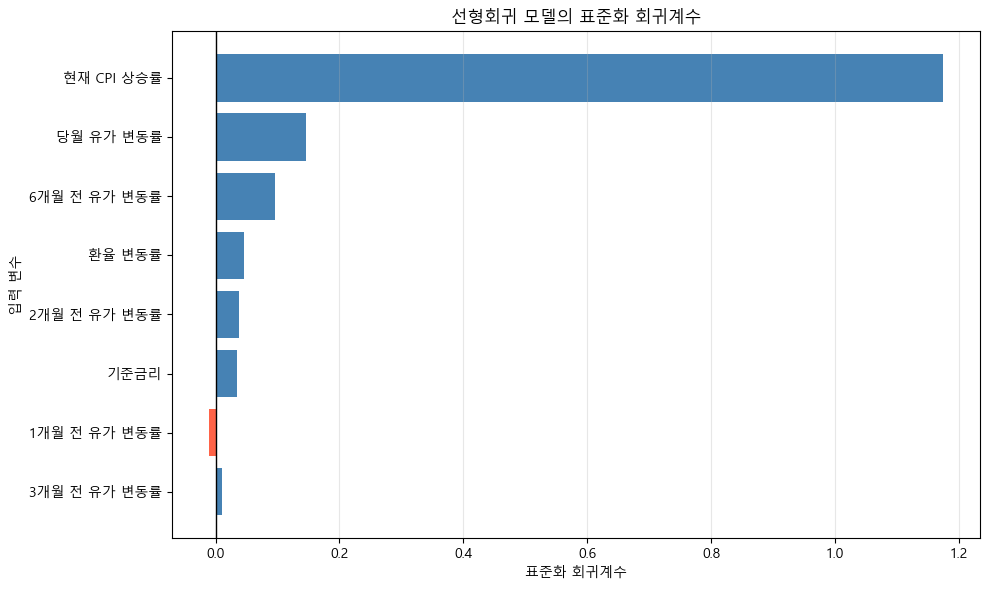

In [40]:
linear_coefficients = pd.DataFrame({
    "Feature": feature_columns,
    "Coefficient": final_model.named_steps["model"].coef_,
})

linear_coefficients["Absolute_Coefficient"] = (
    linear_coefficients["Coefficient"].abs()
)

# 변수명 한글 변환
feature_name_map = {
    "cpi_yoy": "현재 CPI 상승률",
    "oil_mom": "당월 유가 변동률",
    "oil_lag_1": "1개월 전 유가 변동률",
    "oil_lag_2": "2개월 전 유가 변동률",
    "oil_lag_3": "3개월 전 유가 변동률",
    "oil_lag_6": "6개월 전 유가 변동률",
    "fx_mom": "환율 변동률",
    "base_rate": "기준금리",
}

# 출력용 데이터 생성
coefficients_ko = linear_coefficients.copy()

coefficients_ko["변수"] = coefficients_ko["Feature"].replace(
    feature_name_map
)

coefficients_ko = coefficients_ko.rename(columns={
    "Coefficient": "표준화 회귀계수",
    "Absolute_Coefficient": "회귀계수 절댓값",
})

# 회귀계수 절댓값이 큰 순서로 표 출력
display(
    coefficients_ko[
        ["변수", "표준화 회귀계수", "회귀계수 절댓값"]
    ].sort_values(
        "회귀계수 절댓값",
        ascending=False,
    )
)

# 그래프는 작은 값부터 정렬
coefficients_plot = coefficients_ko.sort_values(
    "회귀계수 절댓값",
    ascending=True,
)

plt.figure(figsize=(10, 6))

colors = [
    "tomato" if value < 0 else "steelblue"
    for value in coefficients_plot["표준화 회귀계수"]
]

plt.barh(
    coefficients_plot["변수"],
    coefficients_plot["표준화 회귀계수"],
    color=colors,
)

plt.axvline(0, color="black", linewidth=1)
plt.title("선형회귀 모델의 표준화 회귀계수")
plt.xlabel("표준화 회귀계수")
plt.ylabel("입력 변수")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3 Ridge 규제 최적화

`TimeSeriesSplit` 교차검증에서 최적 `alpha`는 0.001이었다. 테스트 성능도 일반 선형회귀와 사실상 같아 추가 규제가 성능을 개선하지 못했다.


In [21]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge()),
])

param_grid = {
    "model__alpha": [
        0.001, 0.01, 0.1, 1, 10, 100
    ]
}

time_cv = TimeSeriesSplit(n_splits=5)

ridge_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=time_cv,
    n_jobs=-1,
)

ridge_search.fit(X_train, y_train)

best_ridge = ridge_search.best_estimator_
ridge_pred = best_ridge.predict(X_test)

ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print("Best alpha:", ridge_search.best_params_["model__alpha"])
print(f"Ridge MAE:  {ridge_mae:.4f}")
print(f"Ridge RMSE: {ridge_rmse:.4f}")
print(f"Ridge R²:   {ridge_r2:.4f}")

Best alpha: 0.001
Ridge MAE:  0.3036
Ridge RMSE: 0.3602
Ridge R²:   0.9278


## 7. 모델 성능 비교 및 최종 선정

Linear Regression이 MAE 0.3036, RMSE 0.3602, R² 0.9278로 가장 우수했다. Ridge는 거의 같았으나 규제 이점이 없었으므로 성능, 단순성, 해석 가능성을 종합해 **Linear Regression을 최종 모델로 선정**한다.


In [22]:
final_comparison_df = pd.DataFrame([
    {
        "Model": "Persistence Baseline",
        "MAE": baseline_mae,
        "RMSE": baseline_rmse,
        "R2": baseline_r2,
    },
    {
        "Model": "Linear Regression",
        "MAE": linear_mae,
        "RMSE": linear_rmse,
        "R2": linear_r2,
    },
    {
        "Model": "Ridge Regression",
        "MAE": ridge_mae,
        "RMSE": ridge_rmse,
        "R2": ridge_r2,
    },
    {
        "Model": "Random Forest",
        "MAE": rf_mae,
        "RMSE": rf_rmse,
        "R2": rf_r2,
    },
    {
        "Model": "XGBoost",
        "MAE": xgb_mae,
        "RMSE": xgb_rmse,
        "R2": xgb_r2,
    },
]).sort_values("RMSE")

display(final_comparison_df)

,Model,MAE,RMSE,R2
1,Linear Regression,0.303580,0.360205,0.927812
2,Ridge Regression,0.303580,0.360209,0.927811
0,Persistence Baseline,0.309799,0.375895,0.921387
3,Random Forest,0.337438,0.424776,0.899611
4,XGBoost,0.413830,0.575769,0.815557


### 7.1 성능 시각화

RMSE는 낮을수록, R²는 높을수록 우수하다. Linear Regression과 Ridge가 가장 우수하고 단순 지속성 모델보다 소폭 개선된 결과를 확인한다.


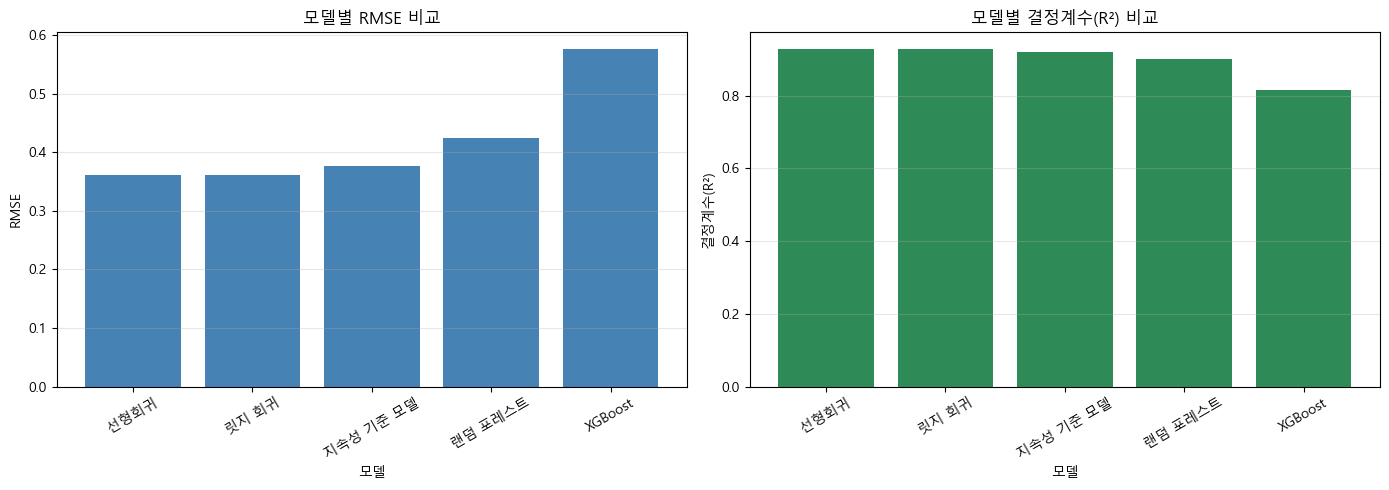

In [39]:
# 그래프 출력용 모델명 한글 변환
model_name_map = {
    "Persistence Baseline": "지속성 기준 모델",
    "Linear Regression": "선형회귀",
    "Ridge Regression": "릿지 회귀",
    "Random Forest": "랜덤 포레스트",
    "XGBoost": "XGBoost",
}

comparison_plot_df = final_comparison_df.copy()
comparison_plot_df["모델"] = comparison_plot_df["Model"].replace(
    model_name_map
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE 비교
axes[0].bar(
    comparison_plot_df["모델"],
    comparison_plot_df["RMSE"],
    color="steelblue"
)
axes[0].set_title("모델별 RMSE 비교")
axes[0].set_xlabel("모델")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(axis="y", alpha=0.3)

# R² 비교
axes[1].bar(
    comparison_plot_df["모델"],
    comparison_plot_df["R2"],
    color="seagreen"
)
axes[1].set_title("모델별 결정계수(R²) 비교")
axes[1].set_xlabel("모델")
axes[1].set_ylabel("결정계수(R²)")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 8. 배포 모델 및 산출물 저장

평가가 끝난 뒤 배포 모델은 정답이 존재하는 전체 기간으로 다시 학습한다. 모델과 입력변수 목록은 `artifacts/cpi_linear_model.joblib`, 가공 데이터는 `dataset/processed/monthly_analysis.csv`로 저장한다.


In [24]:
import joblib
from sklearn.base import clone

ARTIFACT_DIR = Path("./artifacts")
PROCESSED_DIR = Path("./dataset/processed")

ARTIFACT_DIR.mkdir(exist_ok=True)
PROCESSED_DIR.mkdir(exist_ok=True)

# 평가용 2025년 제한을 제거하고 사용 가능한 전체 정답 데이터 사용
deployment_df = analysis_df.dropna(
    subset=feature_columns + ["target_cpi_yoy"]
).copy()

deployment_model = clone(final_model)
deployment_model.fit(
    deployment_df[feature_columns],
    deployment_df["target_cpi_yoy"],
)

# 모델과 입력 컬럼을 함께 저장
joblib.dump(
    {
        "model": deployment_model,
        "feature_columns": feature_columns,
    },
    ARTIFACT_DIR / "cpi_linear_model.joblib",
)

# 정리된 월별 데이터 저장
analysis_df.to_csv(
    PROCESSED_DIR / "monthly_analysis.csv",
    index=False,
    encoding="utf-8-sig",
)

print("모델 저장 완료")

latest_row = (
    analysis_df
    .dropna(subset=feature_columns)
    .iloc[[-1]]
)

latest_prediction = deployment_model.predict(
    latest_row[feature_columns]
)[0]

prediction_month = (
    latest_row["date"].iloc[0]
    + pd.offsets.MonthBegin(1)
)

print("예측 대상 월:", prediction_month.strftime("%Y-%m"))
print(f"예상 CPI 상승률: {latest_prediction:.2f}%")

모델 저장 완료
예측 대상 월: 2026-06
예상 CPI 상승률: 3.28%


## 9. 결론 및 한계

### 9.1 주요 결과

- 현재 물가상승률은 다음 달 물가를 설명하는 가장 강한 변수였다.
- 유가 변수 중 당월 변동률과 6개월 시차 변동률이 상대적으로 높은 예측 기여를 보였다.
- 유가를 추가한 Full Model은 유가 제외 모델보다 RMSE를 약 5.6% 개선했다.
- Linear Regression은 MAE 0.3036, RMSE 0.3602, R² 0.9278로 가장 우수했다.
- 전체 데이터로 재학습한 모델은 2026년 6월 CPI 상승률을 3.28%로 예측했다. 이는 미래 예측치이며 테스트 성능과 구분한다.

### 9.2 한계

1. 월별 표본 수가 제한적이며 금융위기, 코로나19, 지정학적 충격 등 구조 변화가 포함되어 있다.
2. 임금, 수요, 공급망, 재정정책, 기대인플레이션 등 물가의 다른 요인은 포함하지 못했다.
3. 예측력 대부분은 현재 CPI의 자기 지속성에서 나오며 유가와 환율의 추가 개선 폭은 크지 않다.
4. 상관관계와 회귀계수는 인과효과를 의미하지 않는다.
5. 급격한 물가 전환점에서는 예측이 실제 변화보다 늦게 반응한다.

### 9.3 향후 개선 방향

- 수입물가지수, 생산자물가지수, 산업생산, 임금, 기대인플레이션 변수 추가
- 원화 환산 유가 변동률과 유가·환율 상호작용 검토
- 롤링 윈도우 재학습과 구조 변화 탐지
- 월별 데이터 자동 수집·재학습 파이프라인 구축
- Streamlit 기반 최신 예측 및 시나리오 화면 제공
